# Single-cell analysis: LiFi 1.0 (LED) vs LiFi 2.0 (VCSEL)

Phase 1 puts both technologies on equal footing (same normalization power, same room, same photodetector) so that only the channel model changes. Phase 2 replaces that arbitrary power with the power each technology would actually use in practice, which is where the real trade-off between LiFi 1.0 and LiFi 2.0 becomes visible.

Sources used:
- LiFi 1.0 channel (Lambertian, LOS only): Genovés Guzmán et al., "Resource Allocation Exploiting Reflective Surfaces to Minimize the Outage Probability in VLC" — eq. (1), Table III.
- LiFi 2.0 channel (single VCSEL, Gaussian beam): Safi et al., "Energy-Efficient Precoding for Dense VCSEL-Based OWC Systems Under a Cooperative Broadcast Model" — eqs. (2), (6)-(8), Table I, Fig. 4 (FoV values).
- Achievable-rate bound, used for both technologies instead of plain Shannon: Wang et al., "Tight Bounds on Channel Capacity for Dimmable Visible Light Communications" — cited as [39] in the LiFi 1.0 paper and [31] in the LiFi 2.0 paper.
- Eye safety: "Safety Analysis for Laser-based Optical Wireless Communications: A Tutorial" — cited as [14]/[34] in both reference papers. I use their IEC 60825-1:2014 MPE formula and Algorithm 1 for the max eye-safe CW power.
- Eye safety cross-check: Kazemi et al., "Achieving 70 Gb/s Over a VCSEL-Based Optical Wireless Link Using a Multi-Mode Fiber-Coupled Receiver."


## 0. Common scenario

Everything here stays the same across both phases and both technologies: the room, the ceiling/desk height, the transmitter position, the photodetector, and the receiver grid. The only parameters that change later on are the ones related to channel model (Phase 1) and the transmit power (Phase 2).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# room and Tx/Rx geometry, shared by every cell below 
ROOM_X, ROOM_Y = 5.0, 5.0 # room floor size [m], typical attocell footprint
TX_HEIGHT = 3.0 # Tx height, mounted on the ceiling [m]
RX_HEIGHT = 1.0 # Rx height, desk level [m]
TX_POS = np.array([ROOM_X / 2, ROOM_Y / 2, TX_HEIGHT]) # Tx sits at the center of the ceiling
dz = TX_HEIGHT - RX_HEIGHT # vertical Tx-Rx separation [m], used everywhere below

APD = 1e-4 # photodetector active area [m^2] = 1 cm^2, same value in both papers
RHO = 1.0 # photodetector responsivity [A/W], same value in both papers

# receiver grid: N x N points covering the whole floor
N = 300
xs = np.linspace(0, ROOM_X, N)
ys = np.linspace(0, ROOM_Y, N)
X, Y = np.meshgrid(xs, ys)

r0 = np.sqrt((X - TX_POS[0])**2 + (Y - TX_POS[1])**2) # horizontal distance from Tx to each Rx point [m]
d3d = np.sqrt(r0**2 + dz**2) # straight-line Tx-Rx distance [m]
theta = np.arctan2(r0, dz) # irradiance/incidence angle seen from Tx [rad]

print(f"Room {ROOM_X:.0f}x{ROOM_Y:.0f}x{TX_HEIGHT:.0f} m | Tx-Rx vertical separation = {dz:.1f} m")


Room 5x5x3 m | Tx-Rx vertical separation = 2.0 m


## Phase 1 — Ideal single-cell analysis (channel comparison)

In this phase we keep everything constant except the channel model: same room, same Tx/Rx geometry, same $A_{PD}$ and $\rho$, same treatment of the receiver FoV, and both transmitters send the same normalization power, $P_{tx} = 1\,\text{W}$

The 1 W value doesn't mean anything physically, it's just so both technologies are compared under the exact same conditions. The goal of this first analysis is only to see how the Lambertian and the Gaussian-beam models differ, without power getting in the way.

One thing to deicde: how to treat the receiver field of view (FoV) in the VCSEL model.
- Although Safi *et al.* do not explicitly include an angular cut-off in their channel equation, the optical concentrator gain they use corresponds to the classical Kahn-Barry model, where the concentrator gain becomes zero outside the receiver FoV. Since the FoV is a property of the receiver rather than the transmitter, the same angular limitation has been applied to both technologies.
- For completeness, this option has been left as a configurable parameter in the implementation, making it possible to evaluate how sensitive the results are to this assumption.


In [ ]:
# LiFi 1.0: LED, Lambertian, LOS only 
PHI_HALF_DEG = 80.0 # LED half-power semiangle [deg]
FOV_DEG = 40.0 # Rx field-of-view semiangle [deg] (Table III lists 30/40/50, I use 40)

m_led = -1.0 / np.log2(np.cos(np.deg2rad(PHI_HALF_DEG))) # Lambertian order, derived from the half-power angle
FOV = np.deg2rad(FOV_DEG)

H_led = (m_led + 1) * APD / (2 * np.pi * d3d**2) * np.cos(theta)**m_led * np.cos(theta) # LOS Lambertian gain
H_led = np.where(theta <= FOV, H_led, 0.0)  # zero outside the Rx FoV

# LiFi 2.0: single VCSEL, Gaussian beam (Safi et al., eqs. 2, 6-8, Table I) 
W0 = 0.45e-6         # beam waist at the VCSEL aperture [m]
LAMBDA = 950e-9      # VCSEL wavelength [m]
N_LENS = 1.5         # Rx concentrator lens refractive index
THETA_R_DEG = 60.0   # Rx FoV semiangle for the VCSEL, from Fig. 4 (they show 60/90 deg)

APPLY_VCSEL_FOV_CUTOFF = True  # 

theta_r = np.deg2rad(THETA_R_DEG)
G_lens = N_LENS**2 / np.sin(theta_r)**2                    # non-imaging concentrator gain
zR = np.pi * W0**2 / LAMBDA                                # Rayleigh range of the beam [m]
wz = W0 * np.sqrt(1 + (d3d / zR)**2)                       # beam radius at distance d3d [m]
Z_irr = 2 / (np.pi * wz**2) * np.exp(-2 * r0**2 / wz**2)   # Gaussian irradiance profile
H_vcsel = Z_irr * APD * G_lens                             # LOS gain for the VCSEL channel
if APPLY_VCSEL_FOV_CUTOFF:
    H_vcsel = np.where(theta <= theta_r, H_vcsel, 0.0)

print(f"m_led = {m_led:.3f}   |   theta_r={THETA_R_DEG:.0f} deg -> G_lens = {G_lens:.3f}")
print(f"LED FoV disk radius on the desk plane: {dz*np.tan(FOV):.2f} m")
print(f"VCSEL FoV disk radius on the desk plane: {dz*np.tan(theta_r):.2f} m "
      f"(cutoff {'applied' if APPLY_VCSEL_FOV_CUTOFF else 'not applied'})")


m_led = 0.396   |   theta_r=60 deg -> G_lens = 3.000
LED FoV disk radius on the desk plane: 1.68 m
VCSEL FoV disk radius on the desk plane: 3.46 m (cutoff applied)


### Channel-gain maps

Just the shape of each channel, independent of power.


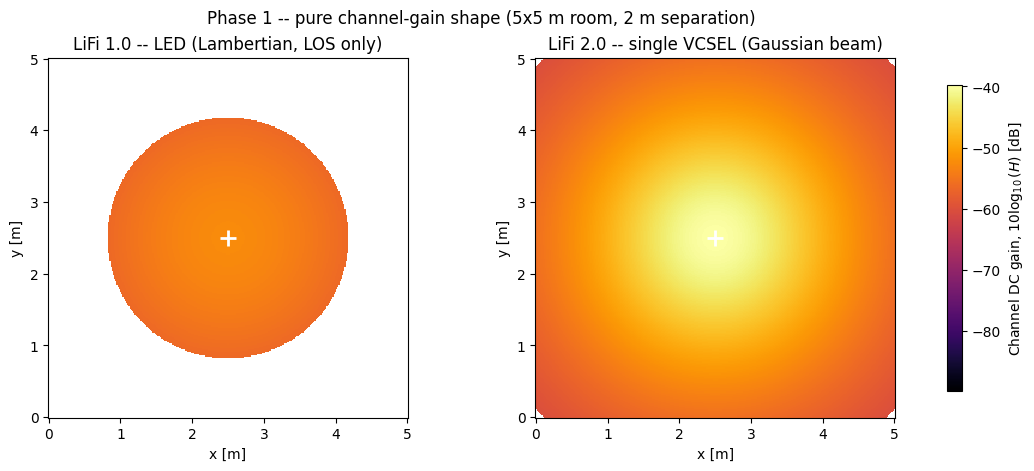

In [3]:
def to_dB(H):
    # channel gain in dB; anything <= 0 becomes NaN so it just doesn't get plotted
    with np.errstate(divide="ignore"):
        return np.where(H > 0, 10 * np.log10(H), np.nan)

H_led_dB = to_dB(H_led)
H_vcsel_dB = to_dB(H_vcsel)
vmax = max(np.nanmax(H_led_dB), np.nanmax(H_vcsel_dB))
vmin = vmax - 50  # 50 dB of dynamic range is enough to see both channels clearly

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), constrained_layout=True)
for ax, H_dB, title in zip(axes, [H_led_dB, H_vcsel_dB],
        ["LiFi 1.0 -- LED (Lambertian, LOS only)", "LiFi 2.0 -- single VCSEL (Gaussian beam)"]):
    im = ax.pcolormesh(X, Y, H_dB, shading="auto", cmap="inferno", vmin=vmin, vmax=vmax)
    ax.plot(*TX_POS[:2], "w+", markersize=12, mew=2)
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_title(title)
    ax.set_aspect("equal")
fig.colorbar(im, ax=axes, label=r"Channel DC gain, $10\log_{10}(H)$ [dB]", shrink=0.85)
fig.suptitle(f"Phase 1 -- pure channel-gain shape ({ROOM_X:.0f}x{ROOM_Y:.0f} m room, {dz:.0f} m separation)")
plt.show()


### Radial profile

Same gain, but sliced along a straight line going outward from directly below the Tx, so the LED and VCSEL shapes are easier to compare.


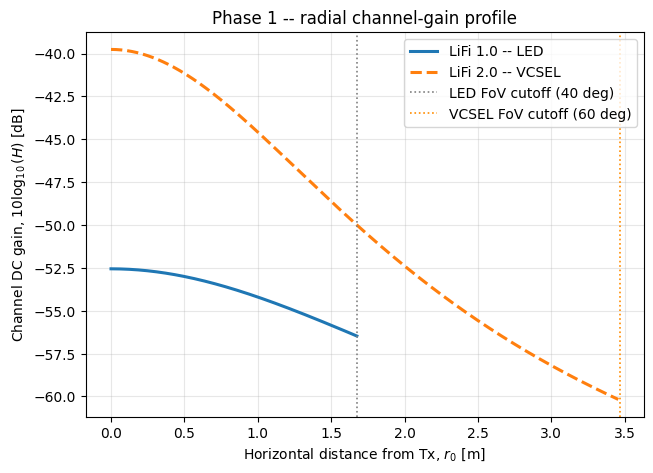

In [4]:
r0_line = np.linspace(1e-3, np.hypot(ROOM_X, ROOM_Y) / 2, 400)  # horizontal distance samples [m]
d_line = np.sqrt(r0_line**2 + dz**2)   # straight-line Tx-Rx distance along that line [m]
th_line = np.arctan2(r0_line, dz)      # incidence angle along that line [rad]

Hl_line = (m_led + 1) * APD / (2 * np.pi * d_line**2) * np.cos(th_line)**m_led * np.cos(th_line)  # same LED formula as before
Hl_line = np.where(th_line <= FOV, Hl_line, np.nan)  # NaN outside FoV so it just doesn't plot

wz_line = W0 * np.sqrt(1 + (d_line / zR)**2)  # VCSEL beam radius along the line [m]
Hv_line = (2 / (np.pi * wz_line**2) * np.exp(-2 * r0_line**2 / wz_line**2)) * APD * G_lens  # same VCSEL formula as before
if APPLY_VCSEL_FOV_CUTOFF:
    Hv_line = np.where(th_line <= theta_r, Hv_line, np.nan)

fig, ax = plt.subplots(figsize=(7.2, 5))
ax.plot(r0_line, 10 * np.log10(Hl_line), lw=2.2, label="LiFi 1.0 -- LED")
ax.plot(r0_line, 10 * np.log10(Hv_line), lw=2.2, ls="--", label="LiFi 2.0 -- VCSEL")
ax.axvline(dz * np.tan(FOV), color="gray", ls=":", lw=1.2, label=f"LED FoV cutoff ({FOV_DEG:.0f} deg)")
if APPLY_VCSEL_FOV_CUTOFF:
    ax.axvline(dz * np.tan(theta_r), color="darkorange", ls=":", lw=1.2, label=f"VCSEL FoV cutoff ({THETA_R_DEG:.0f} deg)")
ax.set_xlabel(r"Horizontal distance from Tx, $r_0$ [m]")
ax.set_ylabel(r"Channel DC gain, $10\log_{10}(H)$ [dB]")
ax.set_title("Phase 1 -- radial channel-gain profile")
ax.legend()
ax.grid(alpha=.3)
plt.show()


### Received power, SNR and achievable rate at the normalization power

The achievable rate is computed using

$$
R=\frac{B}{2}\log_2\left(1+\frac{e}{2\pi}\mathrm{SNR}\right),
$$

which is the lower bound commonly adopted for IM/DD systems. Both reference papers use this expression instead of the classical Shannon capacity because optical wireless communication uses intensity modulation with non-negative signals, making the standard Shannon expression less appropriate.

For the noise, I assume the same PSD $N_0$ for both technologies. The LiFi 1.0 paper gives a value for $N_0$, the LiFi 2.0 paper doesn't, so I reuse the same one for the VCSEL under the assumption that the receiver itself doesn't change. This way any difference in the results comes from the transmitter and the channel, not from an arbitrary noise choice. Even with the same $N_0$, the total noise power still differs between the two because the bandwidth is different (20 MHz for LiFi 1.0, 2 GHz for LiFi 2.0).

This is a simplification — a GHz-class receiver wouldn't really share the exact same noise characteristics as one built for a few tens of MHz — but keeping $N_0$ fixed lets me isolate the effect of the propagation model, which is the actual point of this first phase.


In [ ]:
N0 = 2.5e-20   # noise PSD [W/Hz], from the LiFi 1.0 paper, reused for LiFi 2.0 (see note above)
B1 = 20e6      # LiFi 1.0 bandwidth [Hz], Table III
B2 = 2e9       # LiFi 2.0 bandwidth [Hz], Table I
K_BOUND = np.e / (2 * np.pi)  # constant that appears in the Wang et al. achievable-rate bound

def snr_rate(Ptx_led, Ptx_vcsel):
    Pr_led = Ptx_led * H_led # received optical power, LED [W]
    Pr_vcsel = Ptx_vcsel * H_vcsel # received optical power, VCSEL [W]
    SNR_led = (RHO * Pr_led)**2 / (N0 * B1)
    SNR_vcsel = (RHO * Pr_vcsel)**2 / (N0 * B2)
    R_led = 0.5 * B1 * np.log2(1 + K_BOUND * SNR_led)  # achievable rate, LED [bit/s]
    R_vcsel = 0.5 * B2 * np.log2(1 + K_BOUND * SNR_vcsel) # achievable rate, VCSEL [bit/s]
    return Pr_led, Pr_vcsel, SNR_led, SNR_vcsel, R_led, R_vcsel

PTX_NORM = 1.0  # normalization power for Phase 1 [W], same for both transmitters
Pr_led1, Pr_vcsel1, SNR_led1, SNR_vcsel1, R_led1, R_vcsel1 = snr_rate(PTX_NORM, PTX_NORM)

print(f"Phase 1 @ Ptx = {PTX_NORM:.0f} W (both):")
print(f"  LiFi 1.0 | peak Pr={np.nanmax(Pr_led1)*1e3:.3f} mW | peak SNR={10*np.log10(np.nanmax(SNR_led1)):.1f} dB "
      f"| peak rate={np.nanmax(R_led1)/1e6:.1f} Mbit/s")
print(f"  LiFi 2.0 | peak Pr={np.nanmax(Pr_vcsel1)*1e3:.3f} mW | peak SNR={10*np.log10(np.nanmax(SNR_vcsel1)):.1f} dB "
      f"| peak rate={np.nanmax(R_vcsel1)/1e6:.1f} Mbit/s")


Phase 1 @ Ptx = 1 W (both):
  LiFi 1.0 | peak Pr=0.006 mW | peak SNR=17.9 dB | peak rate=47.9 Mbit/s
  LiFi 2.0 | peak Pr=0.106 mW | peak SNR=23.5 dB | peak rate=6610.3 Mbit/s


### Coverage vs. SNR threshold

Instead of picking one SNR threshold and reporting a single coverage number, I sweep the threshold and plot the whole curve --> it shows a lot more about how the two channels behave 


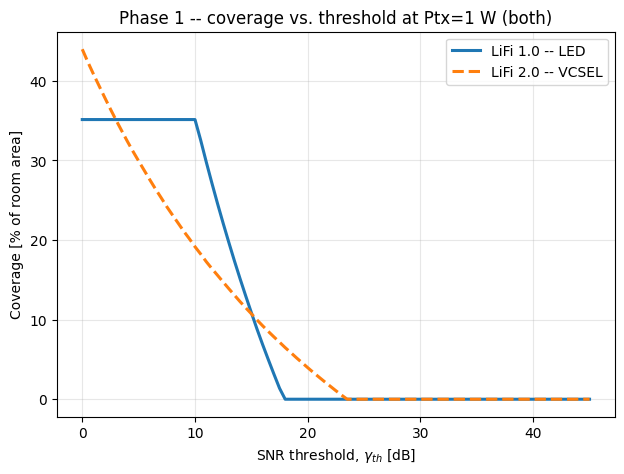

In [6]:
th_range_dB = np.linspace(0, 45, 91)  # SNR thresholds to sweep [dB]
cov_led_curve, cov_vcsel_curve = [], []
for th_dB in th_range_dB:
    g = 10**(th_dB / 10)  # threshold converted to linear scale
    cov_led_curve.append(100 * np.mean(SNR_led1 >= g))      # % of room area above threshold, LED
    cov_vcsel_curve.append(100 * np.mean(SNR_vcsel1 >= g))  # % of room area above threshold, VCSEL

fig, ax = plt.subplots(figsize=(7.2, 5))
ax.plot(th_range_dB, cov_led_curve, lw=2.2, label="LiFi 1.0 -- LED")
ax.plot(th_range_dB, cov_vcsel_curve, lw=2.2, ls="--", label="LiFi 2.0 -- VCSEL")
ax.set_xlabel(r"SNR threshold, $\gamma_{th}$ [dB]")
ax.set_ylabel("Coverage [% of room area]")
ax.set_title(f"Phase 1 -- coverage vs. threshold at Ptx={PTX_NORM:.0f} W (both)")
ax.legend()
ax.grid(alpha=.3)
plt.show()


At low thresholds both systems cover pretty much the whole area their FoV allows, and coverage drops off as the threshold gets stricter, eventually hitting zero.

The point where the two curves cross is interesting: at that point coverage depends only on the channel, not on which technology happens to "win" at some arbitrary threshold. That's really why I plotted the full curve instead of just picking one threshold and comparing a single number.

**Phase 1 takeaway:** every difference here (gain, received power, coverage) comes only from the propagation model (Lambertian vs. Gaussian) and the receiver geometry, because both transmitters use the same power and the same receiver. This phase isolates the channel itself; it doesn't say anything yet about which technology is more practical, since I haven't analyzed transmit power limits or eye safety.


## Phase 2 — Realistic single-cell analysis

Here the question changes. Phase 1 asked "how do the channels compare", Phase 2 asks "what actually happens once each technology is limited by its own real constraints." So instead of the arbitrary 1 W for both, each transmitter now gets the power it would realistically use.


### LiFi 1.0 power — illuminance requirement

I get the LED power from an illuminance target: 500 lux, the standard EN 12464-1 value for office/reading tasks, and also the target used in the LiFi 1.0 reference paper (Sec. V). I reuse the same Lambertian model from Phase 1, just written in terms of illuminance instead of gain — the $A_{PD}$ term cancels out because illuminance describes the light field itself, not any particular detector:

$$E_v(0) = K_{e/v}\cdot P_{tx}\cdot\frac{m+1}{2\pi d_z^2}\quad\Rightarrow\quad
P_{tx}=\frac{E_{target}}{E_v(0)/P_{tx}}$$

The LiFi 1.0 paper's own optimized benchmark (Fig. 15) uses 4 LEDs together reaching 500 lux average in a 4x4x3 m room, with about 82-90 W total (roughly 20-22 W per LED). My single isolated LED needs somewhat more than that per-LED figure, which makes sense as in their case four LEDs share the work of lighting the room, so one LED on its own has to work harder.


In [7]:
KE_V = 280.0          # luminous efficacy [lm/W], Table III
E_TARGET_LUX = 500.0  # illuminance target [lux], EN 12464-1 office value

E_per_watt_boresight = KE_V * (m_led + 1) / (2 * np.pi * dz**2)  # lux produced per watt, directly below the Tx
PTX_LED_REALISTIC = E_TARGET_LUX / E_per_watt_boresight          # LED power needed to hit the target [W]
print(f"LiFi 1.0 realistic power (single LED, {E_TARGET_LUX:.0f} lux target): {PTX_LED_REALISTIC:.1f} W")


LiFi 1.0 realistic power (single LED, 500 lux target): 32.2 W


### LiFi 2.0 power — eye safety (IEC 60825-1:2014)

For the VCSEL, the transmit power is limited by eye-safety requirements.

Unlike LEDs, VCSELs are laser sources, meaning that the maximum optical power of a single emitter is constrained by the IEC 60825-1 laser safety standard. Consequently, a single VCSEL cannot operate at the same optical power as a LED.

To obtain a realistic value, the maximum eye-safe power is estimated following the methodology presented by Soltani *et al.*. This value is also compared with experimentally reported operating powers found in the literature, confirming that practical single-mode VCSELs typically operate in the milliwatt range.


In [8]:
def mpe_point_long_exposure(lam_nm):
    # IEC 60825-1 point-source MPE, 700-1050 nm, 10s-3e4s exposure (Soltani et al. 2022)
    C4 = 10**(0.002 * (lam_nm - 700))
    C7 = 1.0 if lam_nm < 1150 else 10**(0.018 * (lam_nm - 1150))
    return 10 * C4 * C7  # MPE [W/m^2]

assert abs(mpe_point_long_exposure(850) - 19.95) < 0.1  # matches the tutorial's own worked example
MPE_950 = mpe_point_long_exposure(950)

def eye_safe_ptx(w0, lam, rp=3.5e-3):
    # max eye-safe CW power for a single-mode Gaussian VCSEL beam (Soltani et al. 2022, Algorithm 1)
    # w0: beam waist [m], lam: wavelength [m], rp: worst-case dilated pupil radius [m]
    zR_ = np.pi * w0**2 / lam            # Rayleigh range [m]
    theta_div = lam / (np.pi * w0)       # beam divergence half-angle [rad]
    d86 = (np.pi * w0 / lam) * np.sqrt(-2 * rp**2 / np.log(1 - 0.86))  # distance where the pupil catches 86% of the beam power [m]
    if 2 * theta_div > 0.092 and d86 < 0.1:
        zhaz = 0.1  # hazard distance capped at 10 cm for wide-divergence beams
    else:
        alpha = 2 * np.arctan(w0 / d86)
        zhaz = w0 / 0.0021 if alpha < 1.5e-3 else 9.2 * np.pi * w0 / (2 * lam)  # most hazardous viewing distance [m]
    Wzhaz = w0 * np.sqrt(1 + (zhaz / zR_)**2)  # beam radius at the hazard distance [m]
    eta = 1 - np.exp(-2 * rp**2 / Wzhaz**2)    # fraction of beam power that enters the pupil there
    return (1 / eta) * mpe_point_long_exposure(950) * np.pi * rp**2, zhaz, eta

PTX_VCSEL_EYESAFE, zhaz, eta = eye_safe_ptx(W0, LAMBDA)
PTX_VCSEL_EXPERIMENTAL = 5e-3  # Kazemi et al. 2025, ref [8], real 940 nm VCSEL operating power

print(f"MPE(950nm, point source, long exposure) = {MPE_950:.1f} W/m^2")
print(f"Theoretical eye-safe ceiling (single bare VCSEL, w0={W0*1e6:.2f} um): {PTX_VCSEL_EYESAFE*1e3:.1f} mW")
print(f"Real experimental operating power (Kazemi et al. 2025, ref [8]):     {PTX_VCSEL_EXPERIMENTAL*1e3:.1f} mW")
print(f"\nRatio LED/VCSEL realistic power: {PTX_LED_REALISTIC/PTX_VCSEL_EYESAFE:.0f}x (vs. eye-safety ceiling) "
      f"/ {PTX_LED_REALISTIC/PTX_VCSEL_EXPERIMENTAL:.0f}x (vs. experimental value)")


MPE(950nm, point source, long exposure) = 31.6 W/m^2
Theoretical eye-safe ceiling (single bare VCSEL, w0=0.45 um): 224.9 mW
Real experimental operating power (Kazemi et al. 2025, ref [8]):     5.0 mW

Ratio LED/VCSEL realistic power: 143x (vs. eye-safety ceiling) / 6430x (vs. experimental value)


### Coverage under realistic power

Same SNR-threshold coverage as before, but now with each technology's own realistic power 


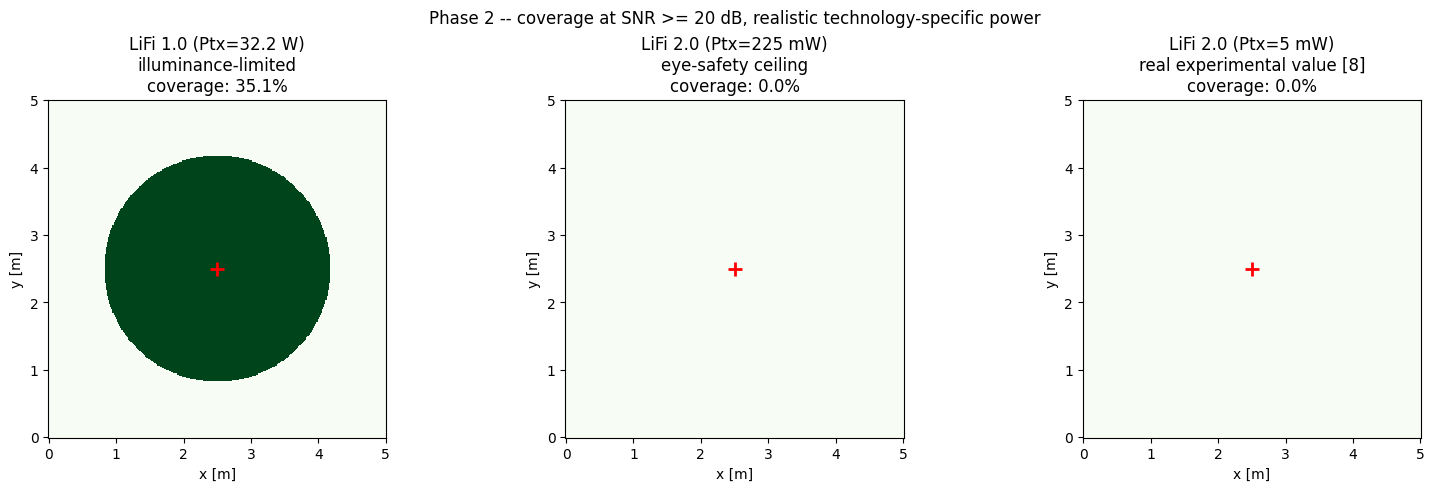

In [9]:
_, _, SNR_led_re, SNR_vcsel_eyesafe, _, R_vcsel_eyesafe = snr_rate(PTX_LED_REALISTIC, PTX_VCSEL_EYESAFE)
_, _, _, SNR_vcsel_exp, _, R_vcsel_exp = snr_rate(PTX_LED_REALISTIC, PTX_VCSEL_EXPERIMENTAL)

GAMMA_TH_DB = 20.0  # SNR threshold used to define "covered" [dB]
gamma_th = 10**(GAMMA_TH_DB / 10)
cov_led_re = SNR_led_re >= gamma_th                    # coverage map, LED at realistic power
cov_vcsel_eyesafe_map = SNR_vcsel_eyesafe >= gamma_th  # coverage map, VCSEL at the eye-safety ceiling
cov_vcsel_exp_map = SNR_vcsel_exp >= gamma_th          # coverage map, VCSEL at the experimental power

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.8), constrained_layout=True)
panels = [
    (cov_led_re, f"LiFi 1.0 (Ptx={PTX_LED_REALISTIC:.1f} W)\nilluminance-limited"),
    (cov_vcsel_eyesafe_map, f"LiFi 2.0 (Ptx={PTX_VCSEL_EYESAFE*1e3:.0f} mW)\neye-safety ceiling"),
    (cov_vcsel_exp_map, f"LiFi 2.0 (Ptx={PTX_VCSEL_EXPERIMENTAL*1e3:.0f} mW)\nreal experimental value [8]"),
]
for ax, (cov, title) in zip(axes, panels):
    ax.pcolormesh(X, Y, cov, shading="auto", cmap="Greens", vmin=0, vmax=1)
    ax.plot(*TX_POS[:2], "r+", markersize=10, mew=2)
    ax.set_title(f"{title}\ncoverage: {100*cov.mean():.1f}%")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_aspect("equal")
fig.suptitle(f"Phase 2 -- coverage at SNR >= {GAMMA_TH_DB:.0f} dB, realistic technology-specific power")
plt.show()


With power levels each technology could actually use, the single LED covers roughly a third of the room, while the single VCSEL barely covers anything — whether I use the theoretical eye-safety ceiling or the much lower experimental value. 


## Interpretation

Phase 2 tells a very different story than Phase 1.

In Phase 1, since both transmitters used the same power, I could compare the channel models directly, and the VCSEL came out ahead near the beam axis just because it concentrates power more tightly.

But that's not how a real system would operate. Once I switch to realistic powers, everything comes down to how much optical power each transmitter is actually allowed to emit. An LED can put out the watts needed for room illumination without any issue; a single VCSEL is stuck in the milliwatt range because of eye-safety limits.

This is exactly why LiFi 2.0 doesn't rely on a single VCSEL — it uses arrays of them. Instead of pushing more power out of one emitter, you combine many low-power ones, which is the architecture the VCSEL reference paper actually analyzes.


## Scaling analysis: from one VCSEL to an array

Phase 2 leaves an obvious question hanging: a single VCSEL barely covers anything under eye-safety limits, so what happens if I don't use just one, but several?

Here I keep the same Tx position, the same room, and the same receiver and SNR threshold as in Phase 2, and I just bundle $N$ VCSELs together at that single point, adding up their optical power directly (VCSELs from different emitters aren't mutually coherent, so intensities add rather than fields). This is *not* yet the real multi-cell architecture — it says nothing about spreading emitters across the ceiling — it's the simplest possible question: if I had $N$ eye-safe VCSELs and just stacked them all at the same spot, how far would that actually get me? I sweep $N$ over powers of two, from 1 up to 64, for both VCSEL power anchors used in Phase 2.


In [ ]:
N_VCSEL_LIST = [1, 2, 4, 8, 16, 32, 64]  # how many VCSELs are bundled at the same Tx point

cov_vs_N_eyesafe, cov_vs_N_exp = [], []          # coverage [%] for each N, one list per power anchor
peak_rate_vs_N_eyesafe, peak_rate_vs_N_exp = [], []  # peak achievable rate [Mbit/s] for each N

for n in N_VCSEL_LIST:
    Ptx_eyesafe_total = n * PTX_VCSEL_EYESAFE       # total optical power of the n-VCSEL bundle, eye-safety anchor
    Ptx_exp_total = n * PTX_VCSEL_EXPERIMENTAL      # total optical power of the n-VCSEL bundle, experimental anchor
    _, _, _, SNR_n_eyesafe, _, R_n_eyesafe = snr_rate(PTX_LED_REALISTIC, Ptx_eyesafe_total)
    _, _, _, SNR_n_exp, _, R_n_exp = snr_rate(PTX_LED_REALISTIC, Ptx_exp_total)
    cov_vs_N_eyesafe.append(100 * np.mean(SNR_n_eyesafe >= gamma_th))
    cov_vs_N_exp.append(100 * np.mean(SNR_n_exp >= gamma_th))
    peak_rate_vs_N_eyesafe.append(np.nanmax(R_n_eyesafe) / 1e6)
    peak_rate_vs_N_exp.append(np.nanmax(R_n_exp) / 1e6)

cov_led_value = 100 * cov_led_re.mean()  # single-LED coverage from Phase 2, just plotted as a reference line

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), constrained_layout=True)

ax = axes[0]
ax.plot(N_VCSEL_LIST, cov_vs_N_eyesafe, "o-", lw=2.2, label="VCSEL array, eye-safety ceiling")
ax.plot(N_VCSEL_LIST, cov_vs_N_exp, "s--", lw=2.2, label="VCSEL array, experimental power [8]")
ax.axhline(cov_led_value, color="gray", ls=":", lw=1.5, label="single LED (reference)")
ax.set_xscale("log", base=2)
ax.set_xticks(N_VCSEL_LIST)
ax.set_xticklabels(N_VCSEL_LIST)
ax.set_xlabel("Number of VCSELs")
ax.set_ylabel("Coverage [% of room area]")
ax.set_title(f"Coverage vs. array size (SNR >= {GAMMA_TH_DB:.0f} dB)")
ax.legend()
ax.grid(alpha=.3)

ax = axes[1]
ax.plot(N_VCSEL_LIST, peak_rate_vs_N_eyesafe, "o-", lw=2.2, label="VCSEL array, eye-safety ceiling")
ax.plot(N_VCSEL_LIST, peak_rate_vs_N_exp, "s--", lw=2.2, label="VCSEL array, experimental power [8]")
ax.set_xscale("log", base=2)
ax.set_xticks(N_VCSEL_LIST)
ax.set_xticklabels(N_VCSEL_LIST)
ax.set_xlabel("Number of VCSELs")
ax.set_ylabel("Peak achievable rate [Mbit/s]")
ax.set_title("Peak rate vs. array size")
ax.legend()
ax.grid(alpha=.3)

plt.show()


Coverage grows quickly at first, but it flattens out well before it reaches the LED's level, and it never gets close to 100% no matter how large $N$ gets. That ceiling has nothing to do with power — it's the VCSEL's own 60° field of view: however much power I pack into the beam, only the disk inside that angle can ever be lit up, and that disk is a lot smaller than the room. Peak rate, on the other hand, keeps climbing, because it only depends on power at a single point, not on how much area is covered.

So bundling more VCSELs together clearly helps, but it runs into a geometric wall that more power alone can't fix. That's exactly what motivates spreading the emitters out instead of stacking them on top of each other.


---

## Transition to the multi-cell analysis

The scaling analysis above already points to the answer: bundling VCSELs at a single point runs into a hard coverage ceiling set by their field of view, no matter how much total power is available. The fix isn't more power in one spot, it's spreading the emitters across the ceiling instead.

That's exactly the setup in Safi et al.: an array of VCSELs distributed over the room rather than stacked together. The next stage of this work moves from this single-transmitter analysis to a multi-cell one, to see what a spatially distributed array can actually achieve.
